In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

2026-03-18 06:23:47.937060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773815027.959149     158 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773815027.966106     158 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773815027.983756     158 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773815027.983778     158 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773815027.983781     158 computation_placer.cc:177] computation placer alr

In [2]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 4480 images belonging to 4 classes.
Found 320 images belonging to 4 classes.


In [3]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(4,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773815045.575172     158 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773815045.581172     158 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [7]:
history = model.fit(
train_data,
epochs=10,
validation_data=val_data
)

Epoch 1/10


I0000 00:00:1773815159.293368     235 service.cc:152] XLA service 0x794bc0005af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773815159.293410     235 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773815159.293416     235 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773815159.717185     235 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-18 06:26:01.549415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 06:26:01.697411: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/140 ━━━━━━━━━━━━━━━━━━━━ 13:59 6s/step - accuracy: 0.2500 - loss: 1.3813

I0000 00:00:1773815163.746610     235 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 182ms/step - accuracy: 0.5597 - loss: 0.9683 - val_accuracy: 0.7219 - val_loss: 0.8157
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.8190 - loss: 0.4809 - val_accuracy: 0.7875 - val_loss: 0.7561
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.8680 - loss: 0.3521 - val_accuracy: 0.7906 - val_loss: 0.7086
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.8934 - loss: 0.2735 - val_accuracy: 0.7906 - val_loss: 0.7726
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9300 - loss: 0.2069 - val_accuracy: 0.8406 - val_loss: 0.6292
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9548 - loss: 0.1298 - val_accuracy: 0.8250 - val_loss: 0.8476
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9541 - loss: 0.1189 - val_accuracy: 0.8531 - val_loss: 0.8377
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9720 - loss: 0.0801 - val_accura

In [8]:
loss, acc = model.evaluate(val_data)

print("Validation Accuracy:", acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8694 - loss: 0.8514
Validation Accuracy: 0.859375


In [9]:
img, label = next(val_data)

prediction = model.predict(img)

print("Predicted:", prediction[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
Predicted: [2.9901522e-01 9.9985588e-01 5.0654053e-04 9.9264342e-01]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

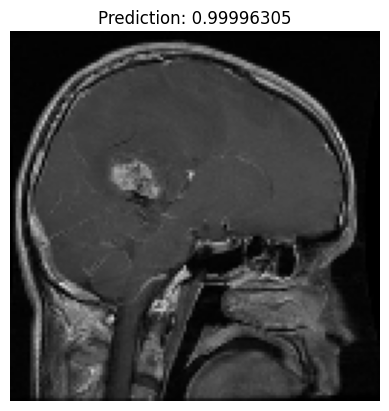

In [10]:
img, label = next(val_data)

prediction = model.predict(img)

plt.imshow(img[0])
plt.title("Prediction: " + str(prediction[0][0]))
plt.axis("off")